In [62]:
import sys
import os
import re

import pandas as pd
import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# NLTK resources (needed for text preprocessing)
nltk.download('stopwords')
nltk.download('wordnet')

# Metrics
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)

from metrics import *

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arianafernandez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/arianafernandez/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [63]:
# Load data
games = pd.read_csv("../data/cleansed/games_cleansed.csv")
ext = pd.read_csv("../data/cleansed/extended_games_cleansed_text.csv")
train = pd.read_csv("../data/cleansed/train_interactions_cleansed.csv")
test_all = pd.read_csv("../data/raw/test_interactions_in.csv")


Each user’s interaction history is split into two parts, a history set (test_in) and a holdout set (test_out). Interactions are randomly shuffled, ensuring that each part contains at least one item.

Users with only one interaction are treated as cold users, since their history cannot be divided.


In [64]:
def split_user_history(df, frac_hist=0.7, seed=42):
    """Split each user's interactions into history (test_in) and holdout (test_out).

    Users with only 1 interaction cannot be split, so they are returned as cold_users.
    """
    rng = np.random.default_rng(seed)

    hist_parts = []
    holdout_parts = []
    cold_users_parts = []

    for _, user_df in df.groupby("user_id"):
        idx = user_df.index.to_numpy()

        if len(idx) == 1:
            cold_users_parts.append(user_df)
            continue

        n_hist = max(1, int(len(idx) * frac_hist))
        shuffled_idx = rng.permutation(idx)

        hist_idx = shuffled_idx[:n_hist]
        holdout_idx = shuffled_idx[n_hist:]

        # Make sure holdout is not empty
        if len(holdout_idx) == 0:
            holdout_idx = hist_idx[-1:]
            hist_idx = hist_idx[:-1]

        hist_parts.append(df.loc[hist_idx])
        holdout_parts.append(df.loc[holdout_idx])

    empty_df = df.head(0)

    test_in = pd.concat(hist_parts) if hist_parts else empty_df
    test_out = pd.concat(holdout_parts) if holdout_parts else empty_df
    cold_users = pd.concat(cold_users_parts) if cold_users_parts else empty_df

    return test_in, test_out, cold_users


Top k recommendations are generated for each user from a score matrix, excluding items the user has already seen. For each user, the k highest scoring items are selected, sorted by score, and returned as a DataFrame with user, item, and rank.

In [65]:
def topk_recommendations(scores, k, seen_items, idx_to_user, idx_to_item):
    """Create top-k recommendations per user from a score matrix.

    Items in seen_items[u_idx] are filtered out (set to -inf).
    Returns a DataFrame with the columns user_id, item_id, rank.
    """
    recommendations = []
    n_users, _ = scores.shape

    for u_idx in range(n_users):
        user_scores = scores.getrow(u_idx).toarray().ravel()

        seen = seen_items.get(u_idx)
        if seen is not None:
            user_scores[list(seen)] = -np.inf

        top_k_idx = np.argpartition(-user_scores, k)[:k]
        top_k_idx = top_k_idx[np.argsort(-user_scores[top_k_idx])]

        for rank, item_idx in enumerate(top_k_idx, start=1):
            recommendations.append([
                idx_to_user[u_idx],
                idx_to_item[item_idx],
                rank
            ])

    return pd.DataFrame(
        recommendations,
        columns=["user_id", "item_id", "rank"]
    )

## Algorithm A: Content-based recommender

A left join is used to enrich the games data with information from ext. The duplicated columns, genres and tags, are then consolidated by keeping the version from games and removing the redundant ones.

In [66]:
# Merge metadata
merged = games.merge(
    ext,
    on=["item_id", "item_name"],
    how="left"
)

merged["genres"] = merged["genres_x"]
merged["tags"]   = merged["tags_x"]

merged = merged.drop(columns=["genres_x", "genres_y", "tags_x", "tags_y"], errors="ignore")
assert merged["item_id"].notna().all(), "missing item_id"

merged.head()

,item_id,item_name,publisher,specs,sentiment,release_date,short_description,about_the_game,detailed_description,reviews,categories,supported_languages,developers,publishers,genres,tags
0,0,Counter-Strike,valve,multi-player valve anti-cheat enabled,overwhelmingly positive,2000-11-01,play the world's number 1 online action game. ...,play the world's number 1 online action game. ...,play the world's number 1 online action game. ...,NaN,multi-player pvp online pvp shared/split scree...,english french german italian spanish - spain ...,valve,valve,action,action fps multiplayer shooter classic team-ba...
1,1,Rag Doll Kung Fu,mark healey,single-player multi-player,mixed,2005-10-12,a piece of steam history - the first ever non ...,a piece of steam history - the first ever non ...,a piece of steam history - the first ever non ...,NaN,single-player multi-player,english,mark healey,mark healey,indie,indie fighting multiplayer
2,2,Silo 2,nevercenter ltd. co.,NaN,mostly positive,2012-12-19,"silo is a focused, lightning-fast standalone 3...",note: this is a legacy version of silo which i...,note: this is a legacy version of silo which i...,NaN,NaN,english,nevercenter ltd. co.,nevercenter ltd. co.,animation & modeling,animation & modeling software
3,3,Call of Duty: World at War,activision,single-player multi-player co-op,very positive,2008-11-18,"call of duty is back, redefining war like you'...","call of duty is back, redefining war like you'...","call of duty is back, redefining war like you'...",NaN,single-player multi-player co-op,english french italian german spanish - spain,treyarch,activision,action,zombies world war ii fps action multiplayer sh...
4,4,3D-Coat V4.8,pilgway,steam cloud,very positive,2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,animation & modeling,animation & modeling


The BoW preprocessing described by Falk is applied to the text metadata. This includes normalization, stopword removal, lemmatization, and stemming. All text fields are then combined into a single document per item to build a suitable representation for TF IDF.

In [67]:
# Falk-style BoW preprocessing

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_falk(text):
    """Basic text cleaning: lowercase, keep letters, remove stopwords, lemmatize + stem."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()

    processed_tokens = []
    for tok in tokens:
        if tok in stop_words:
            continue

        tok = lemmatizer.lemmatize(tok)
        tok = stemmer.stem(tok)
        processed_tokens.append(tok)

    return " ".join(processed_tokens)

text_cols = [
    "genres",
    "tags",
    "categories",
    "short_description",
]

for col in text_cols:
    merged[col] = merged[col].fillna("").astype(str).apply(preprocess_falk)

merged["text_falk"] = merged[text_cols].agg(" ".join, axis=1)

merged[["item_id", "item_name", "text_falk"]].head()


,item_id,item_name,text_falk
0,0,Counter-Strike,action action fp multiplay shooter classic tea...
1,1,Rag Doll Kung Fu,indi indi fight multiplay singl player multi p...
2,2,Silo 2,anim model anim model softwar silo focus ligh...
3,3,Call of Duty: World at War,action zombi world war ii fp action multiplay ...
4,4,3D-Coat V4.8,anim model anim model


Each item is assigned a numeric index so it can be used in matrices. Mappings are stored to convert from item IDs to indices and back.

In [68]:
item_ids = merged["item_id"].tolist()

item_to_idx = {}
for i in range(len(item_ids)):
    item_to_idx[item_ids[i]] = i

idx_to_item = np.array(item_ids)
n_items = len(item_ids)


Rows with unknown items are removed, and each item_id is replaced by its numeric index so that the train and test data match the items used by the model.

In [69]:
train_idx = train[train["item_id"].isin(item_to_idx)].copy()
train_idx["item_id"] = train_idx["item_id"].map(item_to_idx)

test_idx = test_all[test_all["item_id"].isin(item_to_idx)].copy()
test_idx["item_id"] = test_idx["item_id"].map(item_to_idx)

Each user’s history is split into a known part (test_in) and an evaluation part (test_out). Cold start users are identified, a numeric index is assigned to each user, and the items already seen by each user are stored so they can be filtered out during recommendation.

In [70]:
# Split test into test_in, test_out and track cold users
test_in, test_out, cold_users = split_user_history(test_idx, frac_hist=0.7, seed=42)

print("Evaluable users:", test_out["user_id"].nunique())
print("Cold-start users:", cold_users["user_id"].nunique())

users_test = test_in["user_id"].unique().tolist()
n_users_test = len(users_test)

# User index mapping for test
user_to_idx_test = {}
idx_to_user_test = {}
for i in range(n_users_test):
    u = users_test[i]
    user_to_idx_test[u] = i
    idx_to_user_test[i] = u

test_in["user_index"] = test_in["user_id"].map(user_to_idx_test)
assert test_in["user_index"].notna().all()

# Items seen in test_in 
seen_items_test = {}
for row in test_in[["user_index", "item_id"]].itertuples(index=False):
    u_idx, item_id = row
    if u_idx not in seen_items_test:
        seen_items_test[u_idx] = set()
    seen_items_test[u_idx].add(item_id)


Evaluable users: 12464
Cold-start users: 1115


A TF IDF item matrix is built from the preprocessed text and normalized using L2.

In [71]:
# TF-IDF item matrix
vectorizer = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.8,
    stop_words="english",
)

X_items_tfidf = vectorizer.fit_transform(merged["text_falk"])
I_A = normalize(X_items_tfidf, norm="l2")

A numeric index is created for each user in the training set and added to the DataFrame so the model matrices can be built.

In [72]:
# User index mapping for train
train_A = train_idx.copy()

users_train = train_A["user_id"].unique().tolist()

user_to_idx_train = {}
for i in range(len(users_train)):
    user_to_idx_train[users_train[i]] = i

train_A["user_index"] = train_A["user_id"].map(user_to_idx_train)
assert train_A["user_index"].notna().all()


The binary user–item training matrix is built and used to aggregate the TF-IDF vectors of the items each user has interacted with, producing a normalized user profile for each user.

In [73]:
# Build train user-item matrix for content profiles
n_users = len(users_train)

values = np.ones(len(train_A), dtype=np.float32)
row_idx = train_A["user_index"].values
col_idx = train_A["item_id"].values

X_ui_train_A = sp.csr_matrix(
    (values, (row_idx, col_idx)),
    shape=(n_users, n_items)
)

U_train = normalize(X_ui_train_A @ X_items_tfidf, norm="l2")



In [74]:
# Build test user profiles from test_in
n_users_test = len(users_test)

values = np.ones(len(test_in), dtype=np.float32)
row_idx = test_in["user_index"].values
col_idx = test_in["item_id"].values

X_ui_test = sp.csr_matrix(
    (values, (row_idx, col_idx)),
    shape=(n_users_test, n_items)
)

U_test = normalize(X_ui_test @ X_items_tfidf, norm="l2")


Cosine similarity scores are computed between user profiles and items. Top 20 recommendations are generated by filtering out seen items, and the model is evaluated using Recall@20 and NDCG@20 on the holdout set test_out.

In [75]:
scores_A = (U_test @ I_A.T).tocsr() #cosine similarity

df_recos_A = topk_recommendations(
    scores_A,
    20,
    seen_items_test,
    idx_to_user_test,
    idx_to_item
)

recall_A = calculate_calibrated_recall(df_recos_A, 20, test_out)
ndcg_A = calculate_ndcg(df_recos_A, 20, test_out)

print("Recall@20:", recall_A)
print("NDCG@20:", ndcg_A)


Recall@20: 0.08190098577212226
NDCG@20: 0.05416091294526842


Item coverage at 20 is computed as the proportion of the full catalog that appears at least once in the top 20 recommendations.

In [76]:
k = 20

item_cov_A = calculate_item_coverage(
    df_recos_A,
    k=k,
    n_items=n_items
)

print("Item coverage@20:", item_cov_A)

Item coverage@20: 0.2807696820368415


## Algorithm B: Collaborative-based recommender

A binary user item training matrix is built for the collaborative model, where each entry indicates whether a user has interacted with an item.

In [77]:
train_B = train_idx.copy()
train_B["user_index"] = train_B["user_id"].map(user_to_idx_train)
assert train_B["user_index"].notna().all()

values = np.ones(len(train_B), dtype=np.float32)

row_indices = train_B["user_index"].values

col_indices = train_B["item_id"].values

X_ui_train_B = sp.csr_matrix(
    (values, (row_indices, col_indices)),
    shape=(n_users, n_items)
)
assert X_ui_train_B.shape == (n_users, n_items)

Item to item cosine similarity is computed from the user item matrix by normalizing dot products with item norms and setting self similarity to zero.

In [78]:
def item_cosine_similarity(X):
    """Item-item cosine similarity from a (user x item) interaction matrix."""
    X = X.tocsr()

    norms = np.sqrt(X.power(2).sum(axis=0)).A1
    norms[norms == 0] = 1.0

    S = (X.T @ X).tocsr()

    # normalize to cosine similarity
    inv_norms = sp.diags(1.0 / norms)
    S = inv_norms @ S @ inv_norms

    S.setdiag(0)
    S.eliminate_zeros()

    return S

For each row of the similarity matrix, only the top k highest values are kept, representing the most similar neighbors, and the rest are removed to obtain a sparse top k matrix.

In [79]:
def topk_on_rows(sim_matrix, k):
    """Keep only top-k values per row in a sparse similarity matrix."""
    sim_matrix = sim_matrix.tolil()

    for i in range(sim_matrix.shape[0]):
        values = sim_matrix.data[i]
        indices = sim_matrix.rows[i]

        if len(values) > k:
            top_idx = np.argpartition(values, -k)[-k:]
            sim_matrix.data[i] = list(np.array(values)[top_idx])
            sim_matrix.rows[i] = list(np.array(indices)[top_idx])

    return sim_matrix.tocsr()

ItemKNN recommendations are computed using top 50 item to item similarities. Top 20 recommendations are generated for each user by filtering out seen items, and the model is evaluated using Recall@20 and NDCG@20 on the holdout set.

In [80]:
S_items = item_cosine_similarity(X_ui_train_B)
S_knn = topk_on_rows(S_items, k=50)

scores_B = (X_ui_test @ S_knn).tocsr()
df_recos_B = topk_recommendations(
    scores_B,
    20,
    seen_items_test,
    idx_to_user_test,
    idx_to_item
)

recall_B = calculate_calibrated_recall(df_recos_B, 20, test_out)
ndcg_B = calculate_ndcg(df_recos_B, 20, test_out)

print("Recall@20:", recall_B)
print("NDCG@20:", ndcg_B)

Recall@20: 0.3102073321416392
NDCG@20: 0.25721606796854535


Item coverage at 20 is computed for the collaborative model as the proportion of the catalog that appears at least once in the top 20 recommendations.

In [81]:
k = 20

item_cov_B = calculate_item_coverage(
    df_recos_B,
    k=k,
    n_items=n_items
)

print("Item coverage@20:", item_cov_B)

Item coverage@20: 0.17423442449841606


Intra list similarity is computed for all models using the same content based item similarity, ensuring a consistent comparison of diversity at the content level.

In [82]:
# Diversity uses the same content-based item similarity for all models
item_similarity_matrix_A = (I_A @ I_A.T).toarray()

ILS_A = calculate_intra_list_sim(df_recos_A, 20, item_similarity_matrix_A)
ILS_B = calculate_intra_list_sim(df_recos_B, 20, item_similarity_matrix_A)

print("ILS@20:", ILS_A)
print("ILS@20:", ILS_B)

ILS@20: 0.4773117308194529
ILS@20: 0.2534416751949361


## Algorithm C: Weighted ensemble recommender

A weighted hybrid is built by combining collaborative and content based scores for different values of alpha. Top 20 recommendations are generated, and accuracy using Recall and NDCG and diversity using ILS and coverage are evaluated to analyze the trade off.

In [83]:
print(scores_A.shape, scores_B.shape)
assert scores_A.shape == scores_B.shape

k = 20
alphas = np.linspace(0, 1, 11) # test different weights for the hybrid

rows = []

for a in alphas:
    hybrid_scores = a * scores_B + (1 - a) * scores_A # weighted blend of CF and CB scores

    # Build top-k recommendations and evaluate
    df_recos_h = topk_recommendations(
        hybrid_scores,
        k,
        seen_items_test,
        idx_to_user_test,
        idx_to_item
    )

    recall = calculate_calibrated_recall(df_recos_h, k, test_out)
    ndcg = calculate_ndcg(df_recos_h, k, test_out)

    ils = calculate_intra_list_sim(df_recos_h, k, item_similarity_matrix_A)
    item_cov = calculate_item_coverage(df_recos_h, k=k, n_items=n_items)

    rows.append([a, 1 - a, recall, ndcg, ils, item_cov])

# Results for different alpha values
df_hybrid = pd.DataFrame(
    rows,
    columns=["alpha_cf", "alpha_cb", "Recall@20", "NDCG@20", "ILS@20", "ItemCoverage@20"]
)

df_hybrid

(12464, 8523) (12464, 8523)


,alpha_cf,alpha_cb,Recall@20,NDCG@20,ILS@20,ItemCoverage@20
0,0.0,1.0,0.081901,0.054161,0.477312,0.280770
1,0.1,0.9,0.270739,0.228578,0.326046,0.285932
2,0.2,0.8,0.294272,0.243264,0.294021,0.267159
3,0.3,0.7,0.302865,0.248917,0.280049,0.249443
4,0.4,0.6,0.306339,0.251553,0.272054,0.230083
5,0.5,0.5,0.307828,0.253542,0.266688,0.214126
6,0.6,0.4,0.308197,0.254721,0.262784,0.196762
7,0.7,0.3,0.308528,0.255496,0.259851,0.186671
8,0.8,0.2,0.309868,0.256283,0.257492,0.179984
9,0.9,0.1,0.310145,0.256599,0.255447,0.177050


## Algorithm D: Switched ensemble recommender

The number of interactions in test_in is counted for each user, and a basic summary is reported.

In [84]:
user_hist_len = test_in.groupby("user_id").size()
user_hist_len.describe()

count    12464.000000
mean        24.659820
std         36.525704
min          1.000000
25%          7.000000
50%         16.000000
75%         32.000000
max       1710.000000
dtype: float64

A switched hybrid is evaluated by using algorithm A for users with few interactions and algorithm B for users with more interactions, based on a threshold T. Accuracy and diversity are then measured for each value of T.

In [85]:
k = 20
thresholds = range(0, 25)
rows = []

for T in thresholds:
    # Split users based on history length
    cold_users = set(user_hist_len[user_hist_len < T].index)
    warm_users = set(user_hist_len[user_hist_len >= T].index)

    # Use CB for cold users and CF for warm users
    df_sw = pd.concat(
        [
            df_recos_A[df_recos_A["user_id"].isin(cold_users)],
            df_recos_B[df_recos_B["user_id"].isin(warm_users)],
        ],
        ignore_index=True,
    )

    recall = calculate_calibrated_recall(df_sw, k, test_out)
    ndcg = calculate_ndcg(df_sw, k, test_out)

    ils = calculate_intra_list_sim(df_sw, k, item_similarity_matrix_A)
    item_cov = calculate_item_coverage(df_sw, k=k, n_items=n_items)

    rows.append([T, recall, ndcg, ils, item_cov])

# Results for different switching thresholds
df_switch_grid = pd.DataFrame(
    rows,
    columns=["threshold_T", "Recall@20", "NDCG@20", "ILS@20", "ItemCoverage@20"]
)

df_switch_grid


,threshold_T,Recall@20,NDCG@20,ILS@20,ItemCoverage@20
0,0,0.310207,0.257216,0.253442,0.174234
1,1,0.310207,0.257216,0.253442,0.174234
2,2,0.297852,0.250672,0.258754,0.263992
3,3,0.269610,0.232379,0.273796,0.291447
4,4,0.260384,0.226383,0.278743,0.294497
5,5,0.248135,0.217392,0.287419,0.298017
6,6,0.238026,0.209449,0.295043,0.299542
7,7,0.232330,0.205523,0.299362,0.301537
8,8,0.221933,0.198090,0.307331,0.302358
9,9,0.213609,0.191937,0.315225,0.301185


## Graphs

We plot how accuracy and diversity change for the weighted hybrid as the weight of the collaborative algorithm alpha varies.

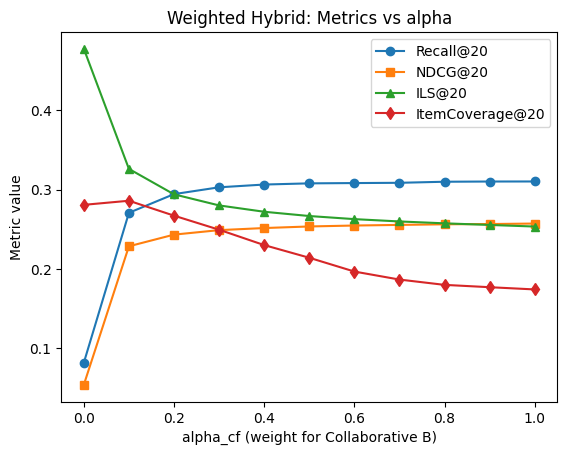

In [86]:
x = df_hybrid["alpha_cf"]

plt.figure()
plt.plot(x, df_hybrid["Recall@20"], marker="o", label="Recall@20")
plt.plot(x, df_hybrid["NDCG@20"], marker="s", label="NDCG@20")
plt.plot(x, df_hybrid["ILS@20"], marker="^", label="ILS@20")
plt.plot(x, df_hybrid["ItemCoverage@20"], marker="d", label="ItemCoverage@20")

plt.xlabel("alpha_cf (weight for Collaborative B)")
plt.ylabel("Metric value")
plt.title("Weighted Hybrid: Metrics vs alpha")
plt.legend()
plt.show()


We plot how accuracy and diversity metrics change for the switched hybrid as the threshold T varies.

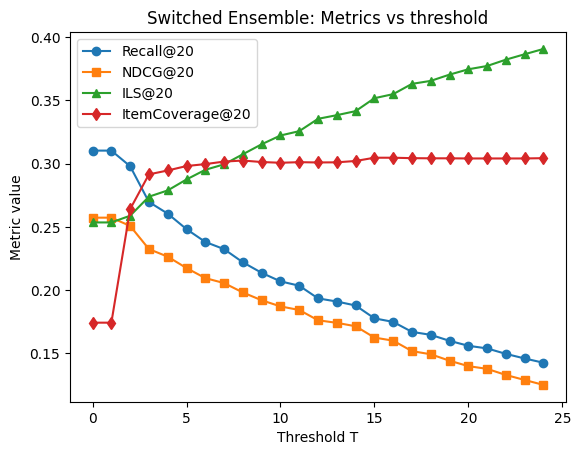

In [87]:
x = df_switch_grid["threshold_T"]

plt.figure()
plt.plot(x, df_switch_grid["Recall@20"], marker="o", label="Recall@20")
plt.plot(x, df_switch_grid["NDCG@20"], marker="s", label="NDCG@20")
plt.plot(x, df_switch_grid["ILS@20"], marker="^", label="ILS@20")
plt.plot(x, df_switch_grid["ItemCoverage@20"], marker="d", label="ItemCoverage@20")

plt.xlabel("Threshold T")
plt.ylabel("Metric value")
plt.title("Switched Ensemble: Metrics vs threshold")
plt.legend()
plt.show()
